# Mach Zehnder Interferometer

# AIM
Assembling a Mach Zehnder
interferometer to observe the
interference pattern. Determine the
refractive index of air as function of
pressure.

# Apparatus
1. Laser Optics Base Plate
2. Diode Laser with laser mount
3. 2 Beam Splitters with mounts
4. 2 plane mirrors mounted on translational stage
5.  Pressure Cell
6. Screen

# Theory
Optical interference corresponds to the interaction of two or more light waves yielding a resultant
irradiance that deviates from the sum of the component irradiances. It can be achieved in broadly
two different ways: wave-front splitting (e.g.: Young’s double-slit experiment) and amplitude splitting (e.g.: Michaelson Interferometer, Mach Zehnder
Interferometer).

The Mach Zehnder interferometer uses a coherent light beam from a suitable source which is split into
two parts using an optical component such as a beam splitter. These partial beams travel along two
different paths until they are deflected using mirrors and channeled to a detector behind another
beam-splitter where they combine and superimpose. If the coherence between the two partial
beams is not destroyed it will result in interference forming circular fringes on the screen.

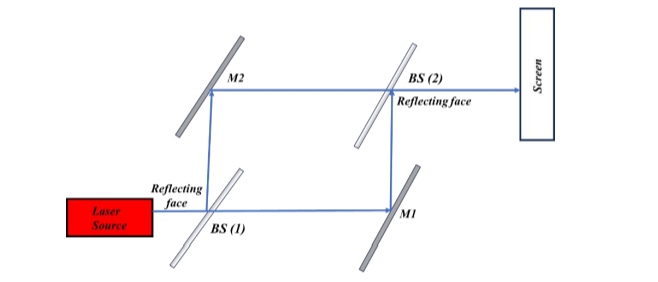

Above is a diagram detailing the configuration and alignment of the setup.
It basically consists of 2 beam splitters and 2 reflecting surfaces, angled at 45$^{\circ}$. The beam splitter 1 is placed such to split the trajectory of the light ray into two orthogonal light paths. The mirrors M1 and M2 reflect them, and the splitter BS2 brings them together.
It is very important that we ensure the path lengths are the same, otherwise interference will not occur. If interference is done properly, we will see concentric fringes like so:

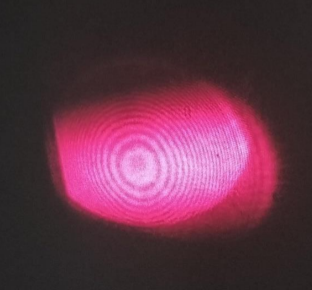

Afterwards, we place a pressure cell, labelled in the image below:

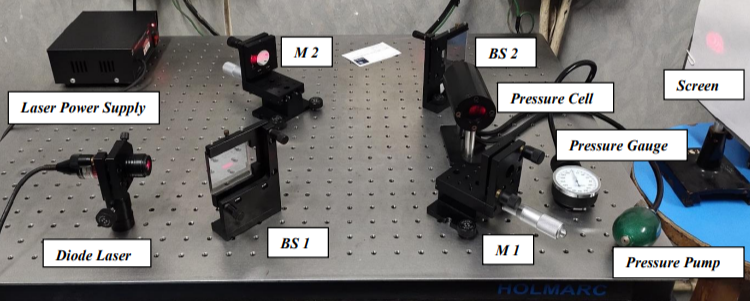

# Formulae

We will see shift of m-fringes due to a
change in the refractive index by an amount
$Δn = mλ/L$

The refractive index for most gases is close to 1. For air and other ideal gases, the difference between
the refractive index is proportional to the pressure of the gas. Thus, we will define the refractive index of
air as:

$n = 1 + kp$

where $p$ is the air pressure and $k$ is an unknown constant. So, when the pressure is changed, it affects
the refractive index as:

$n = kΔp$.

We can, therefore, relate the number of fringes shifted, 𝑚, to
change in pressure:

$Δp = Δn/k = mλ/(Lk)$.

The above equation can be rewritten as:
$P_{final} = -\frac{mλ}{Lk} + P_{initial}$

Thus, plotting the graph between the Pressure and the corresponding fringe shift can help in
determining the constant "k" given by

$k = \frac{-λ}{L(slope)}$

Where L is the path travelled by the laser beam inside the pressure cell.




# Error Analysis

We have,

$k = \frac{-λ}{L(slope)}$

Differentiating above,

$Δk = \frac{λ(Δslope)}{L(slope)^2}$

which gives,

$Δn = \frac{λ(Δslope)}{L(slope)^2}$P

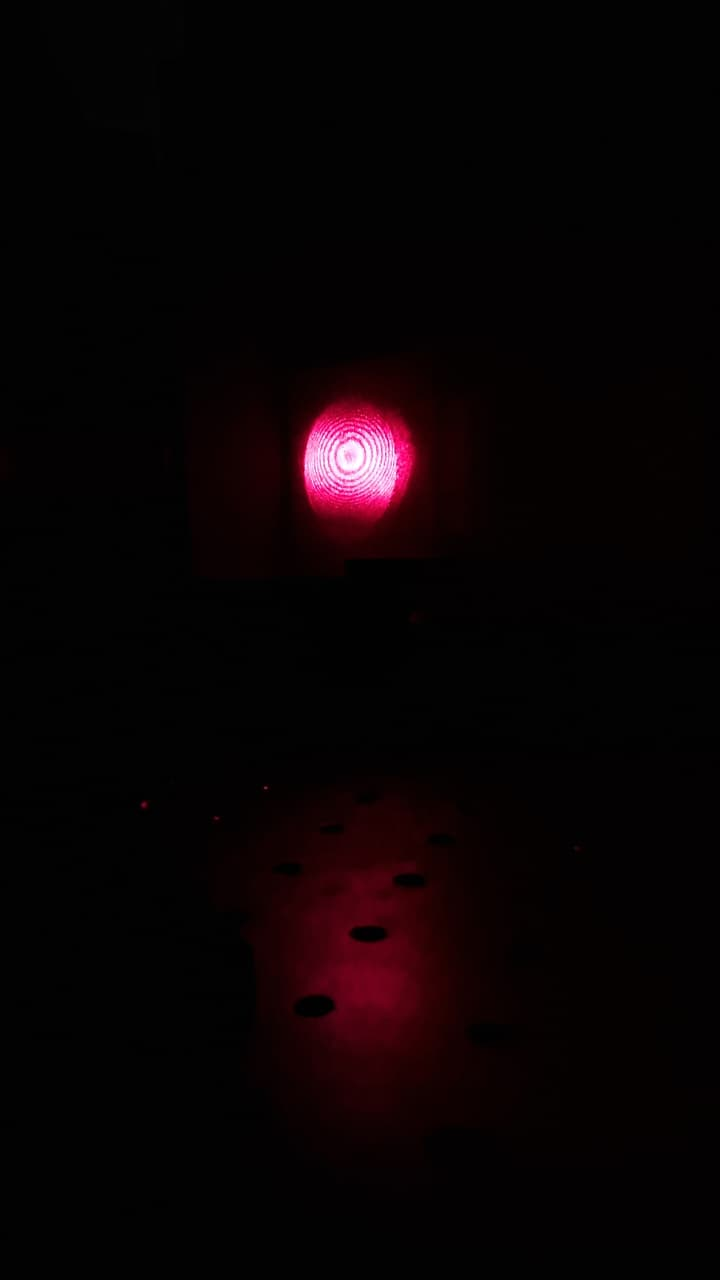

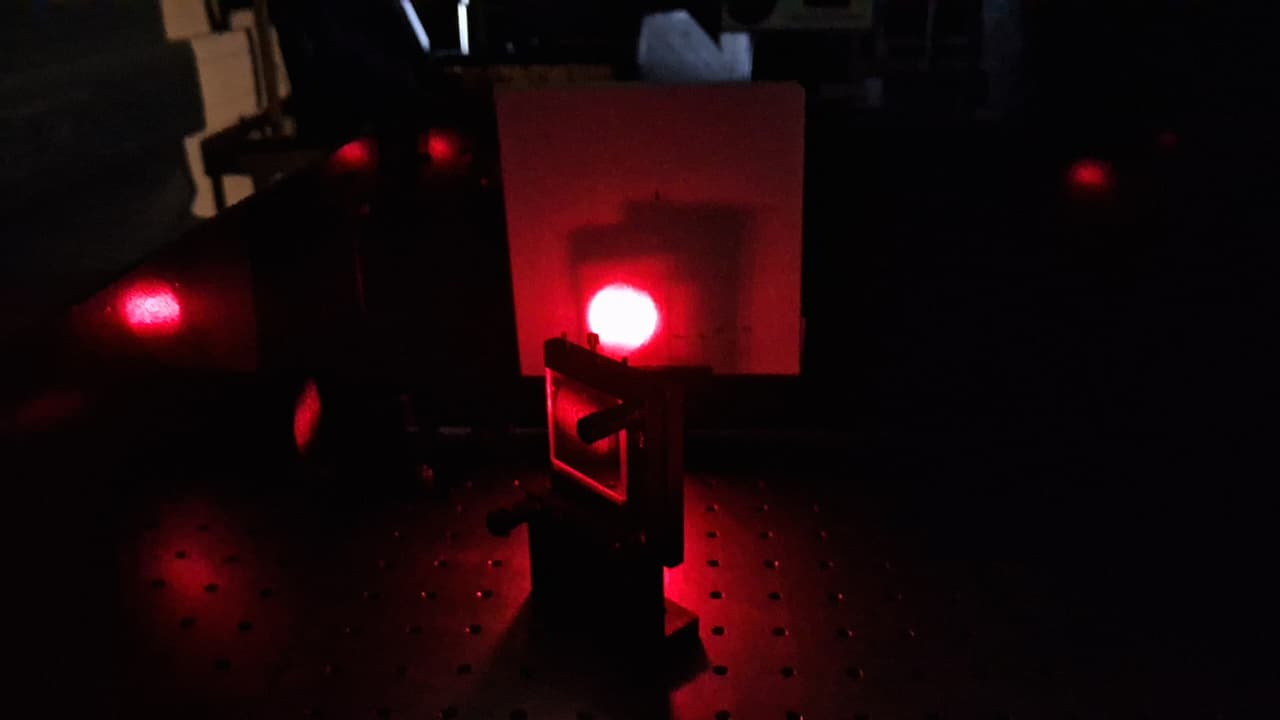

Above are the images of our setup once aligned, the analysis part follows below.

# Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

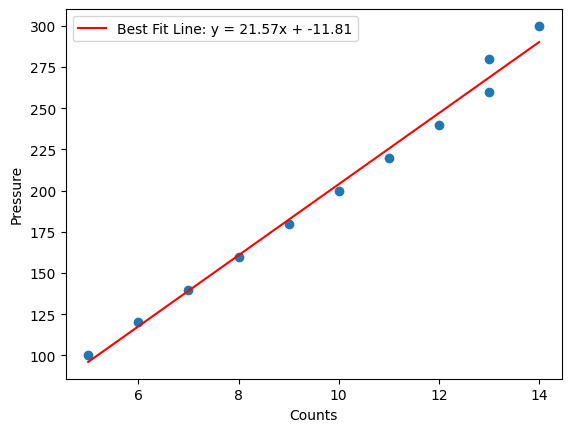

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     927.4
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           2.17e-10
Time:                        06:57:34   Log-Likelihood:                -35.679
No. Observations:                  11   AIC:                             75.36
Df Residuals:                       9   BIC:                             76.15
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.8058      7.256     -1.627      0.1

In [ ]:
data = pd.read_csv('Experiment 2.csv')
counts = data["Count"].to_numpy()
P = data["Pressure"].to_numpy()

"""
P_initial represents the initial pressure reading (starting point of the sphygmomanometer), while P_final denotes the final pressure endpoint

We plot P_initial versus fringe counts, the governing relation is: P_initial = P_final + (count * lambda) / (L * k)

where: L = 9 cm is the effective optical path length, lambda = 650 nm is the wavelength of the light source
"""
X = sm.add_constant(counts)
model = sm.OLS(P, X)
results = model.fit()

slope = results.params[1]
intercept = results.params[0]
error_slope = results.bse[1]

equation = f'y = {slope:.2f}x + {intercept:.2f}'

plt.scatter(counts, P)
plt.plot(counts, results.predict(X), color='red', label=f'Best Fit Line: {equation}')
plt.xlabel("Counts")
plt.ylabel("Pressure")
plt.legend()
plt.show()

print(results.summary())

In [ ]:
lam = 650e-9 # 650 nm
L = 9e-2 # 9 cm
k = lam/(L*slope)
n = 1 + k*760 # Atmospheric Pressure

error_k = lam * error_slope/(L*slope**2)
error_n = lam/L * error_slope/slope**2 * 760

print(f'k = {k}+-{error_k}')
print(f'n = {n}+-{error_n}')


k = 3.347834783478346e-07+-1.0993576076137007e-08
n = 1.0002544354435443+-8.355117817864126e-06


Therefore the refractive index of air is $n = 1.0002544354435443 \pm 8.355117817864126 \times 10^{-6}
$